# Flipkart Review Sentiment Analyzer

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Flipkart_Reviews.csv to Flipkart_Reviews.csv


In [2]:
!pip -q install transformers datasets evaluate accelerate gradio scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import torch
import transformers
print(torch.__version__)
print(transformers.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
5.12.1
True


In [4]:
dataset=pd.read_csv("Flipkart_Reviews.csv")
display(dataset.head())
print(dataset.info())
print(dataset.shape)

,Unnamed: 0,Product_name,Review,Rating
0,0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2304 non-null   int64 
 1   Product_name  2304 non-null   object
 2   Review        2304 non-null   object
 3   Rating        2304 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 72.1+ KB
None
(2304, 4)


In [5]:
dataset=dataset.drop(columns=["Unnamed: 0"],errors="ignore")
dataset=dataset.drop_duplicates().dropna()
dataset=dataset[dataset["Rating"]!=3]
dataset["Sentiment"]=dataset["Rating"].apply(lambda x:1 if x>=4 else 0)
display(dataset.head())

,Product_name,Review,Rating,Sentiment
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5,1
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5,1
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5,1
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5,1
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5,1


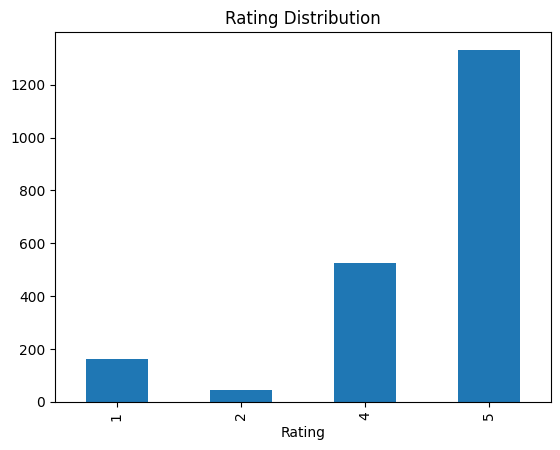

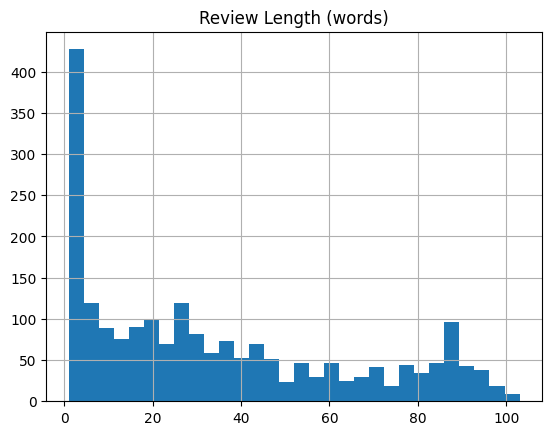

Sentiment
1    1857
0     206
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt

# check rating distribution before we dropped the neutral 3 star reviews
dataset["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.show()


dataset["Review"].str.split().str.len().hist(bins=30)
plt.title("Review Length (words)")
plt.show()

print(dataset["Sentiment"].value_counts())

In [6]:
from sklearn.model_selection import train_test_split
train_df,test_df=train_test_split(dataset,test_size=0.2,random_state=42,stratify=dataset["Sentiment"])

In [7]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
train_enc=tokenizer(train_df["Review"].tolist(),padding=True,truncation=True,max_length=128)
test_enc=tokenizer(test_df["Review"].tolist(),padding=True,truncation=True,max_length=128)

In [9]:
import torch
from torch.utils.data import Dataset
class ReviewDataset(Dataset):
    def __init__(self,e,l): self.e=e; self.l=l.tolist()
    def __getitem__(self,i):
        d={k:torch.tensor(v[i]) for k,v in self.e.items()}; d["labels"]=torch.tensor(self.l[i]); return d
    def __len__(self): return len(self.l)
train_dataset=ReviewDataset(train_enc,train_df["Sentiment"])
test_dataset=ReviewDataset(test_enc,test_df["Sentiment"])

In [20]:
from sklearn.metrics import accuracy_score, f1_score

# so we can see accuracy per epoch instead of just loss
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.054315,0.030547,0.995157,0.997319
2,0.018768,0.168235,0.973366,0.985075
3,0.000278,0.076186,0.987893,0.993307


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=621, training_loss=0.023885172322181004, metrics={'train_runtime': 296.3103, 'train_samples_per_second': 16.705, 'train_steps_per_second': 2.096, 'total_flos': 325599931008000.0, 'train_loss': 0.023885172322181004, 'epoch': 3.0})

In [21]:
model.save_pretrained("flipkart_sentiment_model")
tokenizer.save_pretrained("flipkart_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('flipkart_sentiment_model/tokenizer_config.json',
 'flipkart_sentiment_model/tokenizer.json')

              precision    recall  f1-score   support

    Negative       0.97      0.90      0.94        41
    Positive       0.99      1.00      0.99       372

    accuracy                           0.99       413
   macro avg       0.98      0.95      0.97       413
weighted avg       0.99      0.99      0.99       413



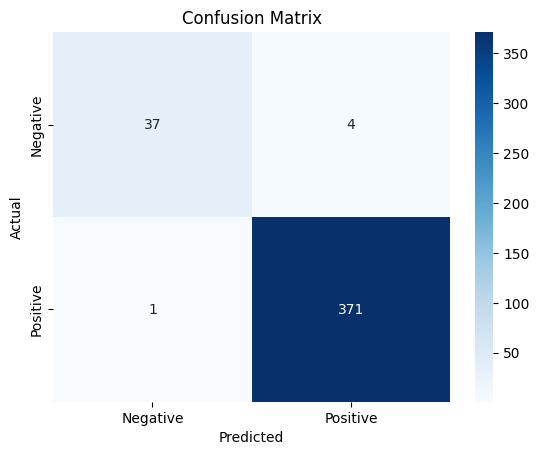

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative","Positive"], yticklabels=["Negative","Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

text = "This phone is amazing!"

inputs = tokenizer(
    text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128
)

# Move inputs to the same device as the model
inputs = {key: value.to(device) for key, value in inputs.items()}

# Prediction mode
model.eval()

with torch.no_grad():
    outputs = model(**inputs)

pred = outputs.logits.argmax(dim=1).item()

print("Positive" if pred == 1 else "Negative")

Positive


In [ ]:
import torch
import gradio as gr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

def predict(review):

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = outputs.logits.argmax(dim=1).item()

    if prediction == 1:
        return "😊 Positive"
    else:
        return "😔 Negative"

app = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=3, placeholder="Enter your Flipkart review..."),
    outputs="text",
    title="Flipkart Review Sentiment Analyzer"
)

app.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d692cc4587bd816c99.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/usr/local/lib/python3.12/di